# Smartwatch Data Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# 3 Boyutlu Veri Görselleştirme Kütüphaneleri
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
df= pd.read_csv("dailyActivity_merged.csv")

In [3]:
#EDA

In [4]:
df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [36]:
df.isnull().sum()

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
Week                        0
dtype: int64

In [11]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])

In [12]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

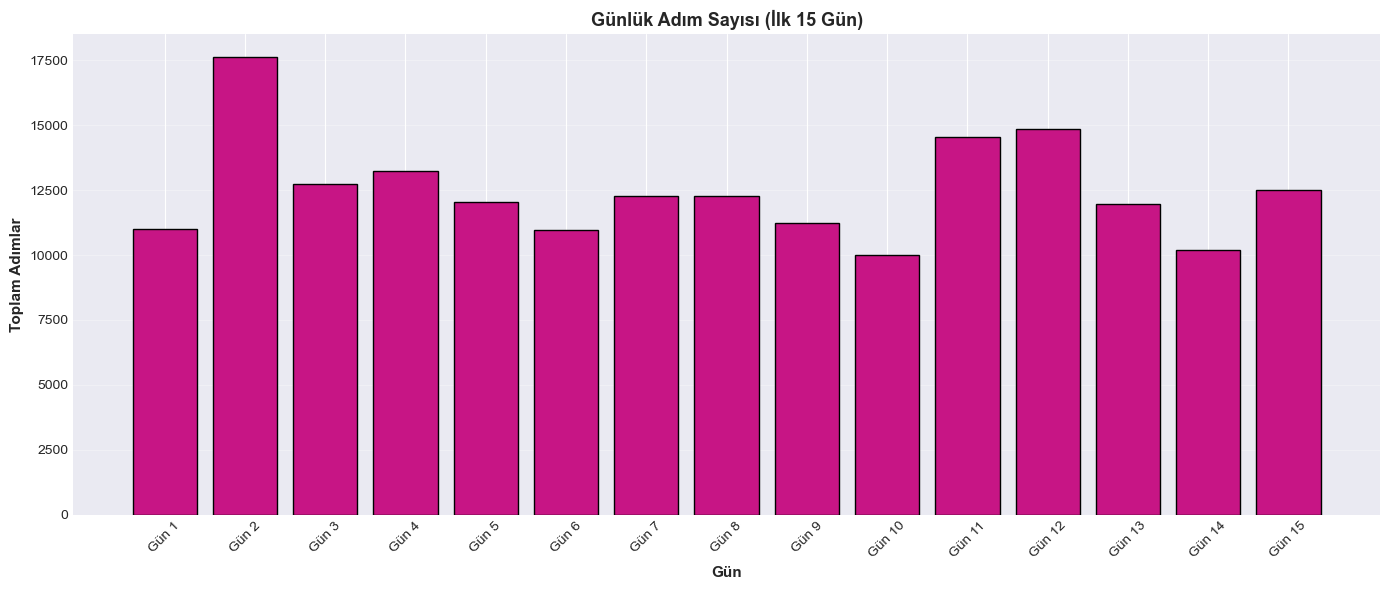

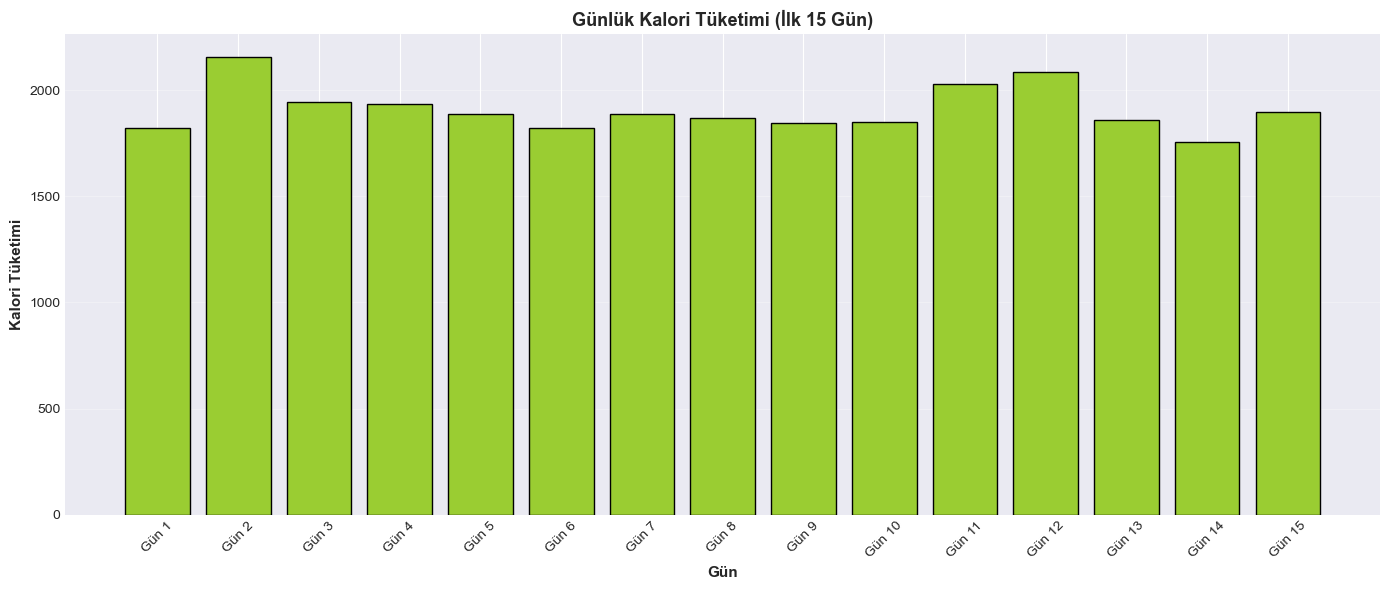

In [34]:
# İlk 15 güne ait Adımlar:
plt.figure(figsize=(14, 6))
df_15_steps = df.head(15)
plt.bar(range(len(df_15_steps)), df_15_steps['TotalSteps'],
color='#C71585', edgecolor='black', linewidth=1)
plt.xlabel('Gün', fontsize=11, fontweight='bold')
plt.ylabel('Toplam Adımlar', fontsize=11, fontweight='bold')
plt.title('Günlük Adım Sayısı (İlk 15 Gün)', fontsize=13, fontweight='bold')
plt.xticks(range(len(df_15_steps)), [f'Gün {i+1}' for i in range(len(df_15_steps))], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#İlk 15 güne ait Kalori:
plt.figure(figsize=(14, 6))
df_15_cal = df.head(15)
plt.bar(range(len(df_15_cal)), df_15_cal['Calories'],
color='#9ACD32', edgecolor='black', linewidth=1)
plt.xlabel('Gün', fontsize=11, fontweight='bold')
plt.ylabel('Kalori Tüketimi', fontsize=11, fontweight='bold')
plt.title('Günlük Kalori Tüketimi (İlk 15 Gün)', fontsize=13, fontweight='bold')
plt.xticks(range(len(df_15_cal)), [f'Gün {i+1}' for i in range(len(df_15_cal))], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

İlk 15 güne ait adım sayıları incelendiğinde genel olarak 10.000 adımın üzerine çıkıldığı görülmektedir, günlük kalori tüketimi de adım sayısı ile doğrusal bir gösterge sunmaktadır.

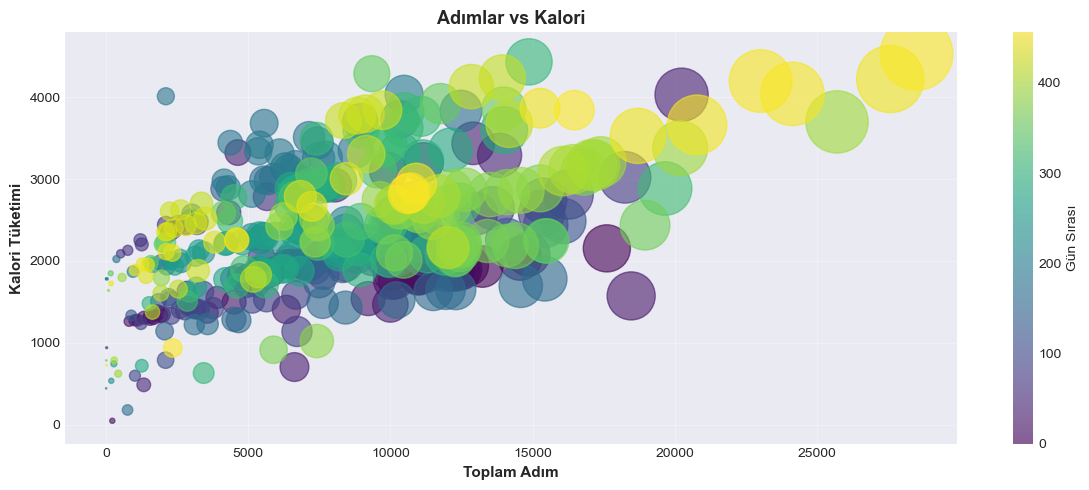

In [21]:
# BUBBLE CHART - Adımlar vs Kalori
plt.figure(figsize=(12, 5))
plt.scatter(df['TotalSteps'], df['Calories'], s=df['TotalDistance']*100, alpha=0.6, c=range(len(df)), cmap='viridis')
plt.xlabel('Toplam Adım', fontsize=11, fontweight='bold')
plt.ylabel('Kalori Tüketimi', fontsize=11, fontweight='bold')
plt.title('Adımlar vs Kalori', fontsize=13, fontweight='bold')
plt.colorbar(label='Gün Sırası')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Adım sayısının artması ile zamana bağlı olarak aktivitelerin düzenli ve uun süreli gerçekleşmesi kalori tüketimini hızlandırmaktadır.

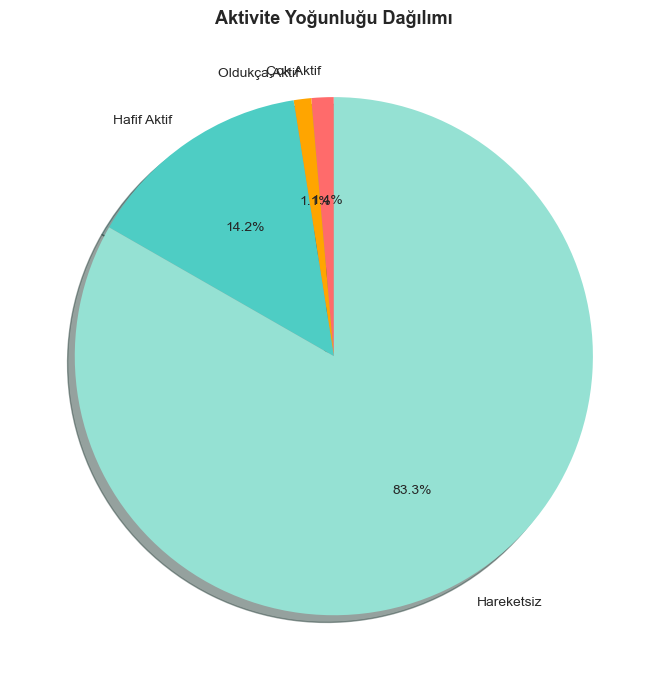

In [38]:
# PIE CHART - Aktivite Yoğunluğu
plt.figure(figsize=(10,7))
activity_mins = [df['VeryActiveMinutes'].sum(), df['FairlyActiveMinutes'].sum(),
df['LightlyActiveMinutes'].sum(), df['SedentaryMinutes'].sum()]
labels = ['Çok Aktif', 'Oldukça Aktif', 'Hafif Aktif', 'Hareketsiz']
colors = ['#FF6B6B', '#FFA500', '#4ECDC4', '#95E1D3']
explode = (0, 0, 0, 0) # gölge
plt.pie(activity_mins, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
explode=explode, shadow=True)
plt.title('Aktivite Yoğunluğu Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

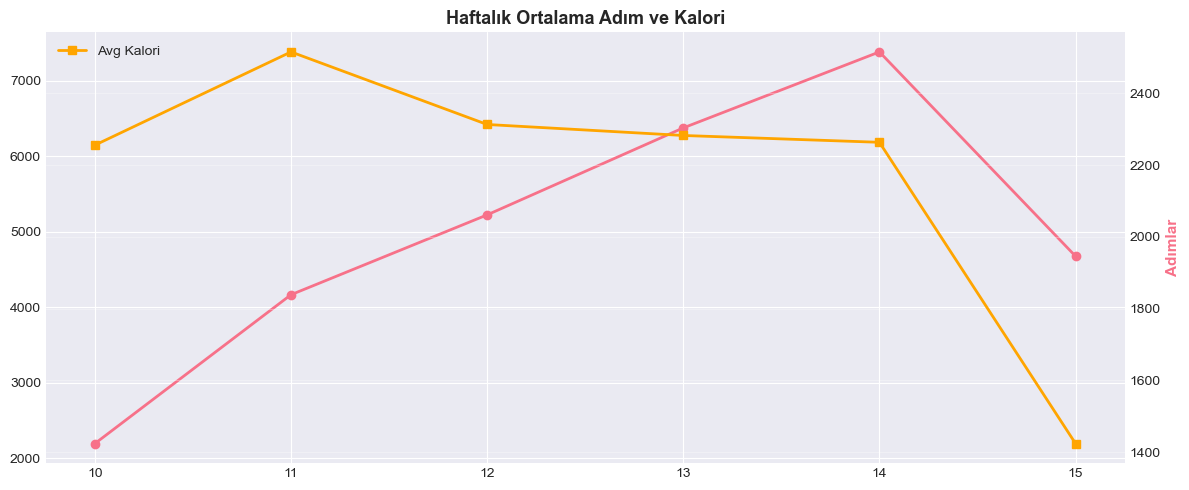

In [40]:
# LINE CHART - Haftalık Ortalama
df['Week'] = df['ActivityDate'].dt.isocalendar().week
weekly = df.groupby('Week')[['TotalSteps', 'Calories']].mean()
plt.figure(figsize=(12, 5))
plt.plot(weekly.index, weekly['TotalSteps'], marker='o', label='Avg Adımlar', linewidth=2)
plt.twinx()
plt.plot(weekly.index, weekly['Calories'], marker='s', label='Avg Kalori', color='orange', linewidth=2)
plt.xlabel('Hafta', fontsize=11, fontweight='bold')
plt.ylabel('Adımlar', fontsize=11, fontweight='bold', color='C0')
plt.title('Haftalık Ortalama Adım ve Kalori', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

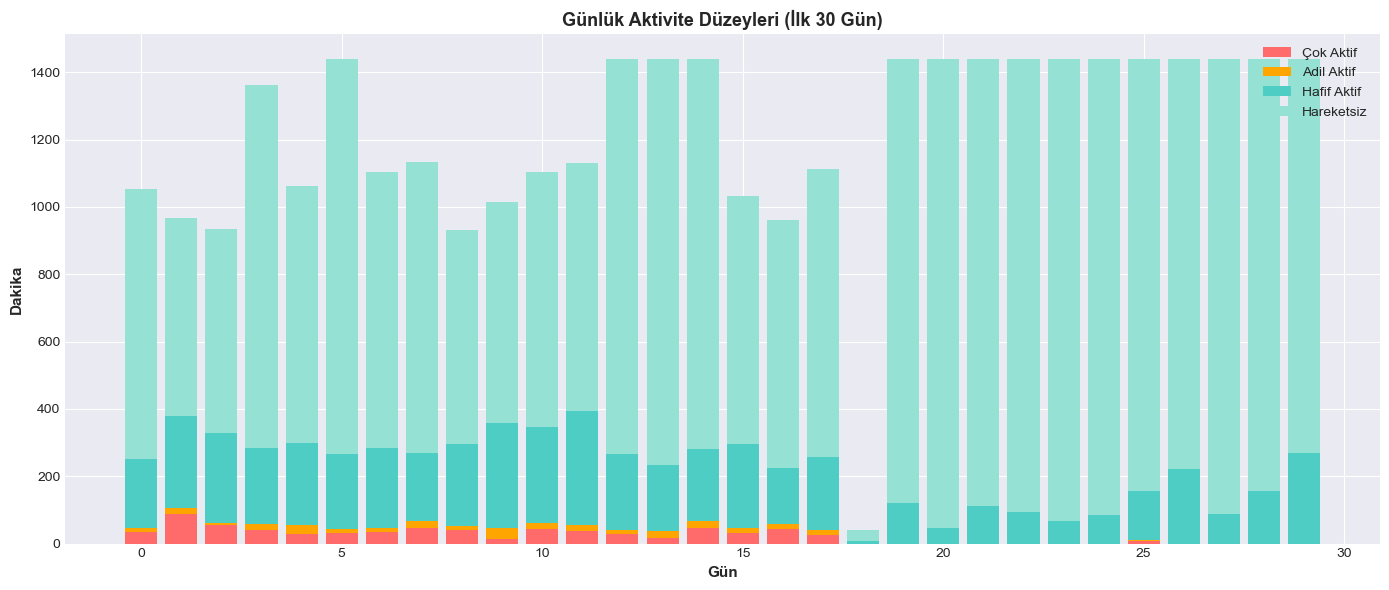

In [18]:
# STACKED BAR CHART - Günlük Aktivite (İlk 30 gün)
df_30 = df.head(30)
plt.figure(figsize=(14, 6))
x = range(len(df_30))
plt.bar(x, df_30['VeryActiveMinutes'], label='Çok Aktif', color='#FF6B6B')
plt.bar(x, df_30['FairlyActiveMinutes'], bottom=df_30['VeryActiveMinutes'], label='Adil Aktif', color='#FFA500')
bottom2 = df_30['VeryActiveMinutes'] + df_30['FairlyActiveMinutes']
plt.bar(x, df_30['LightlyActiveMinutes'], bottom=bottom2, label='Hafif Aktif', color='#4ECDC4')
bottom3 = bottom2 + df_30['LightlyActiveMinutes']
plt.bar(x, df_30['SedentaryMinutes'], bottom=bottom3, label='Hareketsiz', color='#95E1D3')
plt.xlabel('Gün', fontsize=11, fontweight='bold')
plt.ylabel('Dakika', fontsize=11, fontweight='bold')
plt.title('Günlük Aktivite Düzeyleri (İlk 30 Gün)', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

İlk 30 güne ilişkin aktivite yoğunluğu incelendiğinde; kullanıcının genel olarak hareketsiz ve hafif aktif seviyelerinde yoğunluğa sahip olduğu görülmektedir. İlk 15 günde aktivite yoyoğunluğu artmış olsa da sonraki iki hafta bu yoğunluk seyrelmiştir.

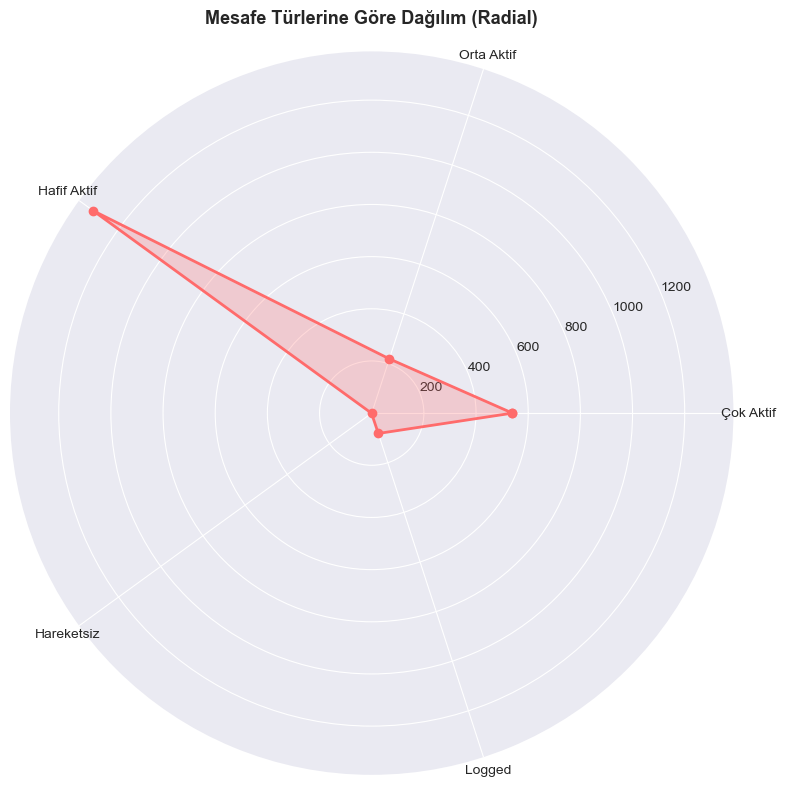

In [17]:
#POLAR CHART - Mesafe Türleri
categories = ['Çok Aktif', 'Orta Aktif', 'Hafif Aktif', 'Hareketsiz', 'Logged']
values = [df['VeryActiveDistance'].sum(), df['ModeratelyActiveDistance'].sum(),
          df['LightActiveDistance'].sum(), df['SedentaryActiveDistance'].sum(),
          df['LoggedActivitiesDistance'].sum()]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

plt.figure(figsize=(8, 8))
plt.subplot(111, projection='polar')
plt.plot(angles, values, 'o-', linewidth=2, color='#FF6B6B')
plt.fill(angles, values, alpha=0.25, color='#FF6B6B')
plt.xticks(angles[:-1], categories)
plt.title('Mesafe Türlerine Göre Dağılım (Radial)', fontsize=13, fontweight='bold', pad=20)
plt.grid(True)
plt.tight_layout()
plt.show()

Logged = elle girilmiş veri (manual input) anlamına gelmektedir. Kullanıcı kısa mesafede çok atif iken mesafe arttıkça hafif aktif seviyesinde hareket etmetkedir.

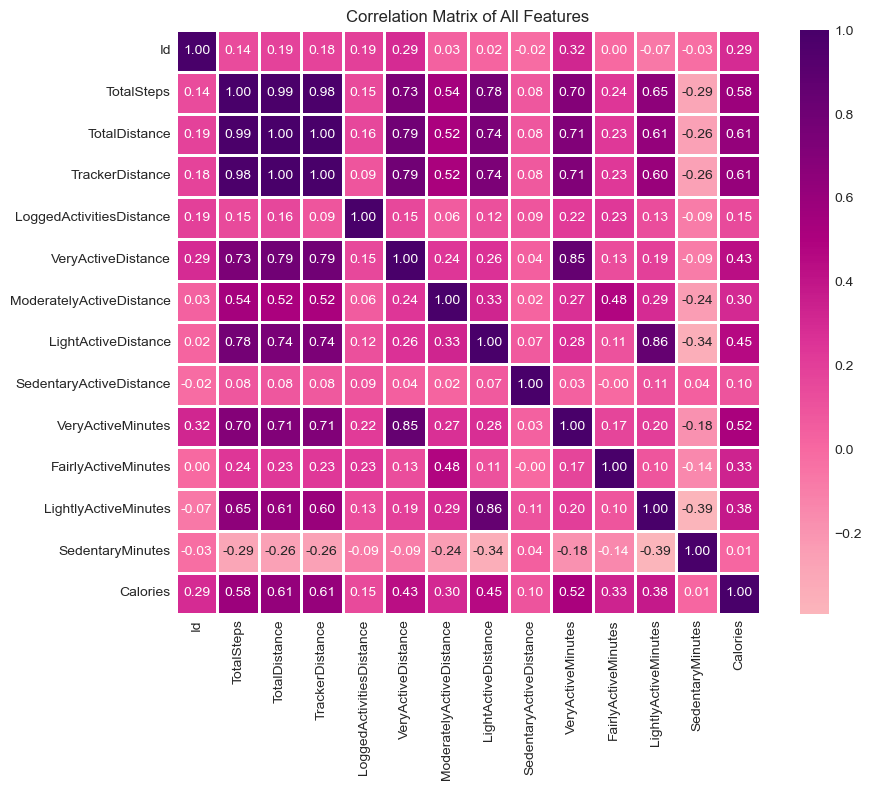

In [13]:
# Correlation Heatmap
num = df.select_dtypes(include='number')
correlation_matrix = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdPu', center=0,fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

Korelasyon haritası incelendiğinde; 
Bazı değişkenler arasında oldukça doğrusal bir orantı olduğu görülmektedir.
TotalSteps & TotalDistance (0.99) arasında adım sayısı arttıkça katedilen mesafe de neredeyse birebir artamaktadır.
TotalDistance & TrackerDistance (1.00) cihazın ölçtüğü mesafe ile toplam mesafe tamamen örtüştüğünü göstermektedir.

Kalori tüketimini en çok etkileyen etmenler;
TotalDistance & TotalSteps (0.61 - 0.58): Adım sayısı ve mesafe artışına bağlı olarak kalori yakımı artış göstermektedir.
VeryActiveMinutes (0.52): "Çok aktif" geçen süre, kalori yakımında "hafif aktif" sürelere (0.38) göre daha etkilidir yani egzersiz şiddeti arttıkça kalori verimi de artmaktadır.

Aktivite Türleri ve Mesafe İlişkisi
VeryActiveDistance & VeryActiveMinutes (0.85): Çok aktif olunan süre ile bu sürede katedilen mesafe arasında yüksek bir ilişki bulunmaktadır.
Aynı şekilde LightlyActiveMinutes & LightlyActiveDistance (0.86): Hafif aktivitelerde de süre ve mesafe paralel ilerlemektedir.